# DESEMPAQUETADOR

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# 1. Definir la ruta de tu archivo (usando la ruta que mostró tu consola)
archivo_npz = '/content/dataset_fallrisk_listo.npz'

# 2. Cargar el archivo .npz
print(f"⏳ Desempaquetando datos desde: {archivo_npz}...")
datos = np.load(archivo_npz)

# 3. Extraer los arrays (¡Ya están divididos!)
X_train = datos['X_train']
y_train = datos['y_train']
X_val = datos['X_val']
y_val = datos['y_val']

print(f"\n📊 Forma de X_train (Entrenamiento): {X_train.shape}")
print(f"📊 Forma de X_val (Validación): {X_val.shape}")

# 4. Codificación de las etiquetas (One-Hot Encoding)
# Como la red necesita [1, 0] para ADL y [0, 1] para Caída:
# num_clases = len(np.unique(y_train)) # Ver cuántas clases únicas hay (deberían ser 2)

# y_train_cat = to_categorical(y_train, num_classes=num_clases)
# y_val_cat = to_categorical(y_val, num_classes=num_clases)

print("\n✅ --- RESUMEN DE LA PREPARACIÓN PARA LA CNN+LSTM --- ✅")
print(f"Entrenamiento (Train) -> X: {X_train.shape} | y: {y_train.shape}")
print(f"Validación (Val)    -> X: {X_val.shape}   | y: {y_val.shape}")

⏳ Desempaquetando datos desde: /content/dataset_fallrisk_listo.npz...

📊 Forma de X_train (Entrenamiento): (112913, 100, 6)
📊 Forma de X_val (Validación): (28229, 100, 6)

✅ --- RESUMEN DE LA PREPARACIÓN PARA LA CNN+LSTM --- ✅
Entrenamiento (Train) -> X: (112913, 100, 6) | y: (112913,)
Validación (Val)    -> X: (28229, 100, 6)   | y: (28229,)


In [ ]:
# ==============================================================================
# 1. FILTRADO EXCLUSIVO DE DATOS NORMALES (CRÍTICO)
# ==============================================================================
# IMPORTANTE: Asegúrate de que '0' sea tu clase Normal (ADL).
# Si tu clase normal es '1', cambia el == 0 por == 1.
# Nota: Usamos las etiquetas crudas, NO las codificadas en One-Hot.

print("\n🔍 Filtrando solo datos normales para entrenar al Autoencoder...")
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

print(f"-> Muestras de entrenamiento (solo Normales): {X_train_normal.shape}")
print(f"-> Muestras de validación (solo Normales): {X_val_normal.shape}")


In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. FILTRADO EXCLUSIVO DE DATOS NORMALES (CRÍTICO)
# ==============================================================================
print("\n🔍 Filtrando solo datos normales para entrenar al Autoencoder...")
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

# --- TABLA 1: AUDITORÍA DE DISTRIBUCIÓN ---
print("\n📊 TABLA DE DISTRIBUCIÓN DE CLASES:")
df_distribucion = pd.DataFrame({
    'Conjunto': ['Train Original', 'Train Filtrado', 'Val Original', 'Val Filtrado'],
    'Total Muestras': [len(X_train), len(X_train_normal), len(X_val), len(X_val_normal)],
    'ADL (0)': [np.sum(y_train == 0), len(X_train_normal), np.sum(y_val == 0), len(X_val_normal)],
    'Caídas (1)': [np.sum(y_train == 1), 0, np.sum(y_val == 1), 0]
})
# Imprimimos la tabla formateada
print(df_distribucion.to_markdown(index=False, tablefmt="github"))

# --- TABLA 2: PREVISUALIZACIÓN DE SENSORES ---
print(f"\n👀 PREVISUALIZACIÓN: Primeros 5 instantes de la primera ventana filtrada (Shape: {X_train_normal.shape})")
# Asumimos que el orden de tus columnas es ax, ay, az, gx, gy, gz
columnas_sensores = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# Extraemos la muestra 0, los primeros 5 pasos de tiempo, y todos los canales
df_ventana = pd.DataFrame(X_train_normal[0, :5, :], columns=columnas_sensores)
df_ventana.index.name = "Paso de Tiempo (Timestep)"
print(df_ventana.to_markdown())
print("... (continúa hasta 100 pasos)")


🔍 Filtrando solo datos normales para entrenar al Autoencoder...

📊 TABLA DE DISTRIBUCIÓN DE CLASES:
| Conjunto       |   Total Muestras |   ADL (0) |   Caídas (1) |
|----------------|------------------|-----------|--------------|
| Train Original |           112913 |    106829 |         6084 |
| Train Filtrado |           106829 |    106829 |            0 |
| Val Original   |            14114 |     13354 |          760 |
| Val Filtrado   |            13354 |     13354 |            0 |

👀 PREVISUALIZACIÓN: Primeros 5 instantes de la primera ventana filtrada (Shape: (106829, 100, 6))
|   Paso de Tiempo (Timestep) |       ax |        ay |        az |        gx |         gy |          gz |
|----------------------------:|---------:|----------:|----------:|----------:|-----------:|------------:|
|                           0 | 0.135801 | -0.486388 | -0.603814 | -0.101202 | -0.0399248 | -0.0139678  |
|                           1 | 0.135801 | -0.499435 | -0.603814 | -0.135702 | -0.0516546 | 

# PREPARACION DE VALIDACION

In [ ]:
from sklearn.model_selection import train_test_split

# =====================================================================
# DIVISIÓN FINAL: Validación y Test (80% Train, 10% Val, 10% Test)
# =====================================================================
# Nota: Como X_val original ya representa el 20% del total,
# tomamos el 50% de ese bloque para convertirlo en Test (lo cual es 10% del total).

X_val, X_test, y_val, y_test = train_test_split(
    X_val,              # El bloque de 20% que vino del .npz
    y_val,              # Las etiquetas correspondientes
    test_size=0.5,      # 50% de 20% = 10% del dataset total
    random_state=42,
    stratify=y_val      # Mantenemos la proporción de caídas en ambos sets
)

# Ahora tus variables finales listas para el Pipeline son:
# 1. X_train (El que aumentaremos con Augmentation)
# 2. X_val   (El que usaremos en model.fit para el Early Stopping)
# 3. X_test  (El examen final secreto para evaluar al terminar)

print(f"[INFO] División final completada:")
print(f"-> Train: {X_train.shape[0]} ventanas.")
print(f"-> Val:   {X_val.shape[0]} ventanas.")
print(f"-> Test:  {X_test.shape[0]} ventanas.")

[INFO] División final completada:
-> Train: 112913 ventanas.
-> Val:   14114 ventanas.
-> Test:  14115 ventanas.


# CONFIGURACION

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# ==============================================================================
# CONFIGURACIÓN GENERAL
# ==============================================================================
BATCH_SIZE = 256
EPOCHS = 300
SEQ_LEN = 100     # 2 segundos a 50Hz
NUM_FEATURES = 6  # ax, ay, az, gx, gy, gz
LR = 1e-3

# Asegurar reproducibilidad
tf.keras.utils.set_random_seed(42)

print("🚀 Modo Autoencoder en Keras iniciado.")

# ==============================================================================
# 2. ARQUITECTURA: AUTOENCODER CONVOLUCIONAL 1D EN KERAS
# ==============================================================================
def build_autoencoder(seq_len, input_dim):
    inputs = layers.Input(shape=(seq_len, input_dim))

    # --- ENCODER ---
    # Kernel 5 abarca 100ms de datos. Stride 2 reduce la secuencia de 100 a 50 sin perder contexto temporal.
    x = layers.Conv1D(filters=32, kernel_size=5, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # El cuello de botella: Reducimos de 50 a 25 pasos, y a solo 8 filtros.
    # Pasamos de 600 valores iniciales a un espacio latente de 200 valores (Alta compresión)
    x = layers.Conv1D(filters=8, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    latent = layers.Activation('relu')(x)

    # --- DECODER ---
    # Reconstruimos espacialmente
    x = layers.Conv1DTranspose(filters=32, kernel_size=3, strides=2, padding='same')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Capa de salida: kernel 5 para suavizar la reconstrucción final.
    outputs = layers.Conv1DTranspose(filters=input_dim, kernel_size=5, strides=2, padding='same')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Conv1D_Autoencoder_Optimizado")
    return model

# ==============================================================================
# 3. COMPILACIÓN Y ENTRENAMIENTO
# ==============================================================================
# Instanciamos el modelo
autoencoder = build_autoencoder(SEQ_LEN, NUM_FEATURES)
autoencoder.summary() # Esto imprimirá la tabla de la arquitectura

# Compilador (Mismo optimizador AdamW y Error Cuadrático Medio)
# En Keras moderno, AdamW ya viene incluido
optimizer = optimizers.AdamW(learning_rate=LR, weight_decay=1e-4)
autoencoder.compile(optimizer=optimizer, loss='mse')

🚀 Modo Autoencoder en Keras iniciado.


Model: "Conv1D_Autoencoder_Optimizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 8)          │           776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 8)          │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_4              │ (None, 50, 32)         │           800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_5              │ (None, 100, 6)         │           966 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,822 (14.93 KB)

 Trainable params: 3,678 (14.37 KB)

 Non-trainable params: 144 (576.00 B)

# FUNCION VALIDACION

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

def evaluar_autoencoder(modelo_path, X_val_mixto, y_val_mixto, X_test, y_test):
    """
    Evalúa el Autoencoder calculando primero el umbral óptimo (maximizando F1-Score)
    sobre el conjunto de validación mixto, y luego lo prueba contra datos nunca antes vistos (X_test).
    """
    print(f"\n[INFO] Cargando el mejor modelo desde: {modelo_path}")
    modelo_final = tf.keras.models.load_model(modelo_path, compile=False)

    # =====================================================================
    # 1. CALIBRACIÓN DEL UMBRAL MATEMÁTICO (Usando validación mixta)
    # =====================================================================
    print("📏 Escaneando miles de umbrales con la Curva Precision-Recall...")

    # Predecir y calcular errores en el conjunto de validación
    reconstruccion_val = modelo_final.predict(X_val_mixto, verbose=0)
    mse_val = np.mean(np.square(X_val_mixto - reconstruccion_val), axis=(1, 2))

    # Calcular Precision, Recall y los Umbrales posibles
    precisions, recalls, thresholds = precision_recall_curve(y_val_mixto, mse_val)

    # Calcular el F1-Score para cada umbral (se suma 1e-8 para evitar dividir por cero)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    # Encontrar el umbral que da el mejor F1-Score
    mejor_indice = np.argmax(f1_scores)
    umbral = thresholds[mejor_indice]

    print(f"✨ Umbral de anomalía óptimo fijado en: {umbral:.5f}")
    print(f"   -> F1-Score esperado en validación: {f1_scores[mejor_indice]:.4f}")

    # =====================================================================
    # 2. PREDICCIÓN SOBRE EL SET DE PRUEBA (Examen Final)
    # =====================================================================
    print("\n🔍 Evaluando sobre el Set de Prueba (Normales y Caídas combinadas)...")
    reconstruccion_test = modelo_final.predict(X_test, verbose=0)
    mse_test = np.mean(np.square(X_test - reconstruccion_test), axis=(1, 2))

    # Si el error es mayor al umbral, es una Caída (1), si no, es Normal/ADL (0)
    y_pred = (mse_test > umbral).astype(int)

    # =====================================================================
    # 3. GRÁFICA DE DISTRIBUCIÓN DE ERRORES
    # =====================================================================
    plt.figure(figsize=(10, 6))

    errores_adl = mse_test[y_test == 0]
    errores_caida = mse_test[y_test == 1]

    plt.hist(errores_adl, bins=50, alpha=0.7, color='green', label='Normal (ADL)')
    plt.hist(errores_caida, bins=50, alpha=0.7, color='red', label='Anomalía (Caída)')
    plt.axvline(x=umbral, color='black', linestyle='--', linewidth=2, label=f'Umbral Óptimo ({umbral:.3f})')

    plt.title("Distribución de Errores de Reconstrucción (Autoencoder)")
    plt.xlabel("Error MSE")
    plt.ylabel("Cantidad de Muestras")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # =====================================================================
    # 4. MATRIZ DE CONFUSIÓN
    # =====================================================================
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ADL (0)', 'Caída (1)'],
                yticklabels=['ADL (0)', 'Caída (1)'])
    plt.title("Matriz de Confusión Final (Autoencoder)")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta Real")
    plt.show()

    # =====================================================================
    # 5. REPORTE DE CLASIFICACIÓN
    # =====================================================================
    print("\n=== Reporte de Clasificación Final (Set de Prueba) ===")
    print(classification_report(y_test, y_pred, target_names=['ADL', 'Caída']))

# PIPELINE

In [ ]:
# Callback para guardar el mejor modelo automáticamente (lo que hacías con torch.save)
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Callback opcional: Early Stopping (para detener si deja de mejorar)
early_stopping_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

print("\n🏋️ Comenzando entrenamiento...")
# Fíjate cómo pasamos X_train_normal como ENTRADA y también como SALIDA ESPERADA
history = autoencoder.fit(
    x=X_train_normal,
    y=X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_normal, X_val_normal),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

print("\n💾 Entrenamiento finalizado. El mejor modelo está cargado en memoria y guardado como 'best_autoencoder.keras'")


🏋️ Comenzando entrenamiento...
Epoch 1/300
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5456
Epoch 1: val_loss improved from None to 0.17588, saving model to best_autoencoder.keras

Epoch 1: finished saving model to best_autoencoder.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.3362 - val_loss: 0.1759
Epoch 2/300
413/418 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1448
Epoch 2: val_loss improved from 0.17588 to 0.10594, saving model to best_autoencoder.keras

Epoch 2: finished saving model to best_autoencoder.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1326 - val_loss: 0.1059
Epoch 3/300
407/418 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1091
Epoch 3: val_loss improved from 0.10594 to 0.09138, saving model to best_autoencoder.keras

Epoch 3: finished saving model to best_autoencoder.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1061 - val_loss: 0.0914
Epoch 4/300
409/418 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0982
Epoch 4: val_loss improved


[INFO] Cargando el mejor modelo desde: best_autoencoder.keras
📏 Escaneando miles de umbrales con la Curva Precision-Recall...
✨ Umbral de anomalía óptimo fijado en: 0.29185
   -> F1-Score esperado en validación: 0.4914

🔍 Evaluando sobre el Set de Prueba (Normales y Caídas combinadas)...


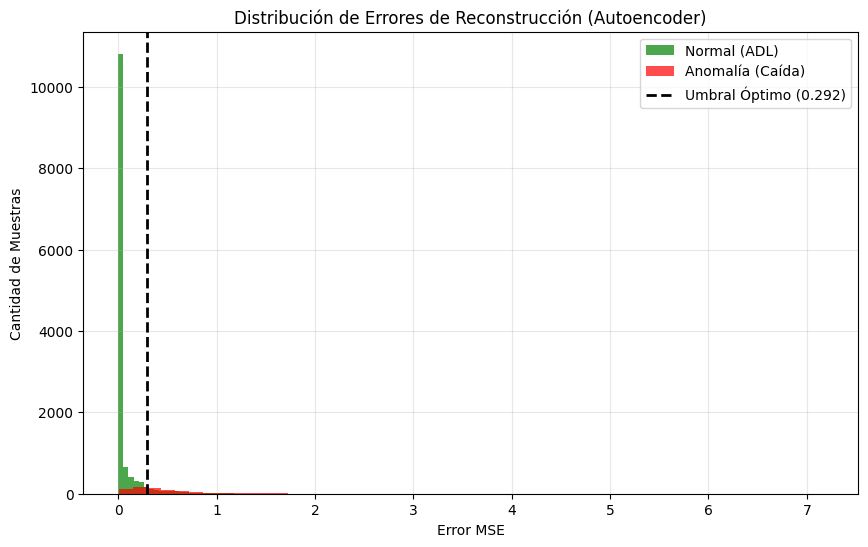

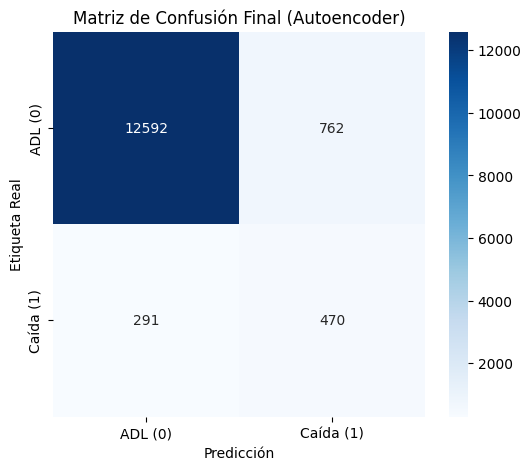


=== Reporte de Clasificación Final (Set de Prueba) ===
              precision    recall  f1-score   support

         ADL       0.98      0.94      0.96     13354
       Caída       0.38      0.62      0.47       761

    accuracy                           0.93     14115
   macro avg       0.68      0.78      0.72     14115
weighted avg       0.95      0.93      0.93     14115



In [ ]:
# Reemplaza tu antigua llamada por esta:
evaluar_autoencoder("best_autoencoder.keras", X_val, y_val, X_test, y_test)